In [1]:
import numpy as np

def make_log_bins(Emin, Emax, N):
    """Return (center, low, high) energies for N log-spaced bins."""
    edges_log = np.linspace(np.log10(Emin), np.log10(Emax), N + 1)
    elo = 10 ** edges_log[:-1]
    ehi = 10 ** edges_log[1:]
    ec = np.sqrt(elo * ehi)          # geometric mean
    return ec, elo, ehi

# ============================================================
# 1) Fermi synthetic spectrum: 50 MeV – 1 TeV (0.05–1000 GeV)
# ============================================================

# Fermi PL parameters from paper (4FGL J1908.6+0915e)
E0_MeV = 4.52e3        # pivot energy 4.52 GeV
F0_MeV = 1.01e-13      # ph / (cm2 s MeV)
Gamma_fermi = 2.23

N_bins_fermi = 20
Emin_fermi_GeV = 0.05   # 50 MeV
Emax_fermi_GeV = 1000.0 # 1 TeV
rel_err_fermi = 0.20    # 20% fractional error

Efermi_c, Efermi_lo, Efermi_hi = make_log_bins(
    Emin_fermi_GeV, Emax_fermi_GeV, N_bins_fermi
)

# Evaluate PL at bin centers (convert E to MeV, then back to per GeV)
E_c_MeV = Efermi_c * 1e3
dnde_MeV = F0_MeV * (E_c_MeV / E0_MeV) ** (-Gamma_fermi)
dnde_GeV = dnde_MeV * 1e3   # per GeV

sigma_fermi = rel_err_fermi * dnde_GeV

fermi_arr = np.column_stack([
    Efermi_c, Efermi_lo, Efermi_hi,
    dnde_GeV, sigma_fermi, sigma_fermi
])

with open("FERMI_SYN_50MeV_1TeV.txt", "w") as f:
    f.write("# energy[GeV]  energy_edge_lo[GeV]  energy_edge_hi[GeV]  "
            "flux[1/(cm2 s GeV)]  flux_err_lo  flux_err_hi\n")
    for row in fermi_arr:
        f.write(" ".join(f"{x:.8e}" for x in row) + "\n")

# ============================================================
# 2) HESS synthetic spectrum: 1 – 10 TeV
# ============================================================

# HESS integral flux and index from paper (HOTS J1907+091)
F_int = 4.3e-13          # F(>1 TeV) [cm^-2 s^-1]
Gamma_hess = 2.3

N_bins_hess = 20
Emin_hess_GeV = 1000.0   # 1 TeV
Emax_hess_GeV = 10000.0  # 10 TeV
rel_err_hess = 0.20      # 20% fractional error

Ehess_c, Ehess_lo, Ehess_hi = make_log_bins(
    Emin_hess_GeV, Emax_hess_GeV, N_bins_hess
)

# Normalisation N0 at 1 TeV, assuming PL integrated from 1 TeV to infinity:
# F_int = ∫_{E0}^{∞} N0 (E/E0)^(-Gamma) dE = N0 * E0 / (Gamma - 1)
E0_GeV = 1000.0          # 1 TeV
N0_hess = F_int * (Gamma_hess - 1.0) / E0_GeV

dnde_hess = N0_hess * (Ehess_c / E0_GeV) ** (-Gamma_hess)
sigma_hess = rel_err_hess * dnde_hess

hess_arr = np.column_stack([
    Ehess_c, Ehess_lo, Ehess_hi,
    dnde_hess, sigma_hess, sigma_hess
])

with open("HESS_SYN_1TeV_10TeV.txt", "w") as f:
    f.write("# energy[GeV]  energy_edge_lo[GeV]  energy_edge_hi[GeV]  "
            "flux[1/(cm2 s GeV)]  flux_err_lo  flux_err_hi\n")
    for row in hess_arr:
        f.write(" ".join(f"{x:.8e}" for x in row) + "\n")

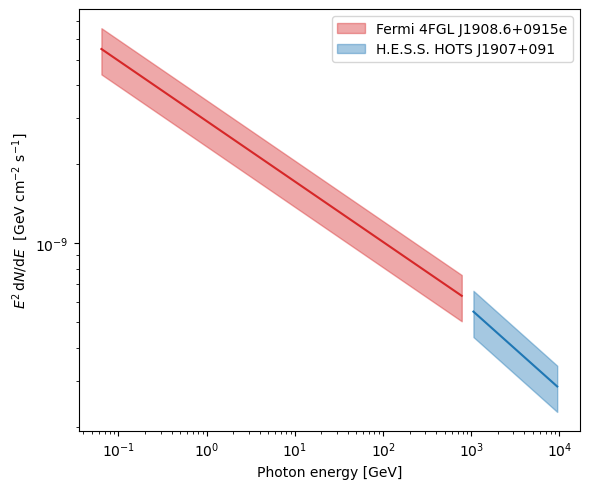

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ----------------- I/O -----------------
def load_sed(fname):
    data = np.loadtxt(fname)
    E, Elo, Ehi, F, Ferr_lo, Ferr_hi = data.T
    return E, Elo, Ehi, F, Ferr_lo, Ferr_hi

E_f, Elo_f, Ehi_f, F_f, dFf_lo, dFf_hi = load_sed("FERMI_SYN_50MeV_1TeV.txt")
E_h, Elo_h, Ehi_h, F_h, dFh_lo, dFh_hi = load_sed("HESS_SYN_1TeV_10TeV.txt")

# ----------------- SED = E^2 dN/dE -----------------
# F - dF can be tiny; clip to stay positive for log axis
F_f_lo = np.clip(F_f - dFf_lo, 1e-99, None)
F_f_hi = F_f + dFf_hi

F_h_lo = np.clip(F_h - dFh_lo, 1e-99, None)
F_h_hi = F_h + dFh_hi

SED_f    = E_f**2 * F_f
SED_f_lo = E_f**2 * F_f_lo
SED_f_hi = E_f**2 * F_f_hi

SED_h    = E_h**2 * F_h
SED_h_lo = E_h**2 * F_h_lo
SED_h_hi = E_h**2 * F_h_hi

# ----------------- Plot -----------------
fig, ax = plt.subplots(figsize=(6, 5))

# Fermi (red band)
ax.fill_between(E_f, SED_f_lo, SED_f_hi,
                alpha=0.4, color="tab:red", label="Fermi 4FGL J1908.6+0915e")
ax.plot(E_f, SED_f, color="tab:red")

# HESS (blue band)
ax.fill_between(E_h, SED_h_lo, SED_h_hi,
                alpha=0.4, color="tab:blue", label="H.E.S.S. HOTS J1907+091")
ax.plot(E_h, SED_h, color="tab:blue")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Photon energy [GeV]")
ax.set_ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E$  [GeV cm$^{-2}$ s$^{-1}$]")

ax.legend(loc="best")

# optional: nice minor ticks
ax.xaxis.set_minor_locator(mticker.LogLocator(subs="auto"))
ax.yaxis.set_minor_locator(mticker.LogLocator(subs="auto"))

plt.tight_layout()
plt.show()

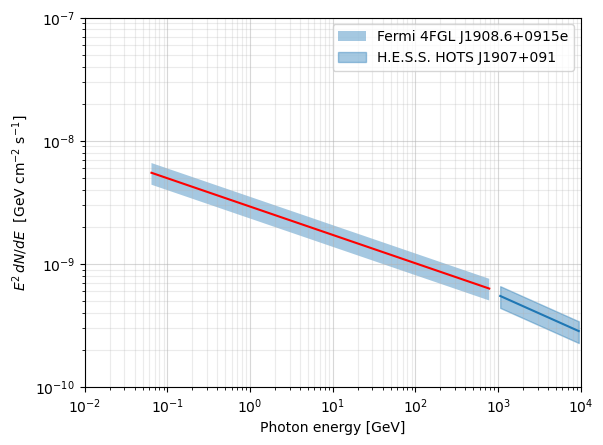

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# helper to read the ASCII files we just wrote
def load_sed(fname):
    data = np.loadtxt(fname)
    E, Elo, Ehi, F, Ferr_lo, Ferr_hi = data.T
    return E, Elo, Ehi, F, Ferr_lo, Ferr_hi

E_f, Elo_f, Ehi_f, F_f, dFf_lo, dFf_hi = load_sed("FERMI_SYN_50MeV_1TeV.txt")
E_h, Elo_h, Ehi_h, F_h, dFh_lo, dFh_hi = load_sed("HESS_SYN_1TeV_10TeV.txt")

# convert to E^2 dN/dE (for SED-style plot)
SED_f = E_f**2 * F_f
SED_f_lo = E_f**2 * (F_f - dFf_lo)
SED_f_hi = E_f**2 * (F_f + dFf_hi)

SED_h = E_h**2 * F_h
SED_h_lo = E_h**2 * (F_h - dFh_lo)
SED_h_hi = E_h**2 * (F_h + dFh_hi)

fig, ax = plt.subplots()

# Fermi band (red)
ax.fill_between(E_f, SED_f_lo, SED_f_hi, alpha=0.4, label="Fermi 4FGL J1908.6+0915e")
ax.plot(E_f, SED_f, "r-")

# HESS band (blue)
ax.fill_between(E_h, SED_h_lo, SED_h_hi, alpha=0.4, color="C0", label="H.E.S.S. HOTS J1907+091")
ax.plot(E_h, SED_h, color="C0")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-2, 1e4)
ax.set_ylim(1e-10, 1e-7)
ax.set_xlabel("Photon energy [GeV]")
ax.set_ylabel(r"$E^2\,dN/dE$  [GeV cm$^{-2}$ s$^{-1}$]")

# More ticks on log axes
subs = np.arange(1, 10) * 0.1  # 1–9 within each decade
ax.xaxis.set_major_locator(mticker.LogLocator(base=10, numticks=30))
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=subs, numticks=100))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=30))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=subs, numticks=100))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())  # hide minor labels (optional)
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.legend()
ax.grid(True, which="major", alpha=0.5)
ax.grid(True, which="minor", alpha=0.25)

plt.show()

Generating Synthetic Gamma-Ray Spectrum
Based on Hnatyk et al. 2022 methodology

Error Envelope Analysis

Fermi-LAT (50 MeV - 1 TeV):
  Pivot energy: 4.52 GeV
  Min relative error: 0.190 at 5.45 GeV
  Max relative error: 0.592 at 1000.00 GeV
  Error at lowest energy: 0.498
  Error at highest energy: 0.592

H.E.S.S. (1 TeV - 10 TeV):
  Pivot energy: 7.0 TeV
  Min relative error: 0.201 at 6951.93 GeV
  Max relative error: 0.452 at 1000.00 GeV
  Error at lowest energy: 0.452
  Error at highest energy: 0.214

Error Envelope Shape Explanation:
1. Errors are SMALLEST at the pivot energy (where fit is anchored)
2. Errors GROW moving away from pivot (bow-tie pattern)
3. Growth rate depends on spectral index uncertainty
4. H.E.S.S. has larger baseline uncertainty (20% vs ~19%)
5. Asymmetric errors arise from multiplicative/log-normal nature

Generating basic spectrum plot...


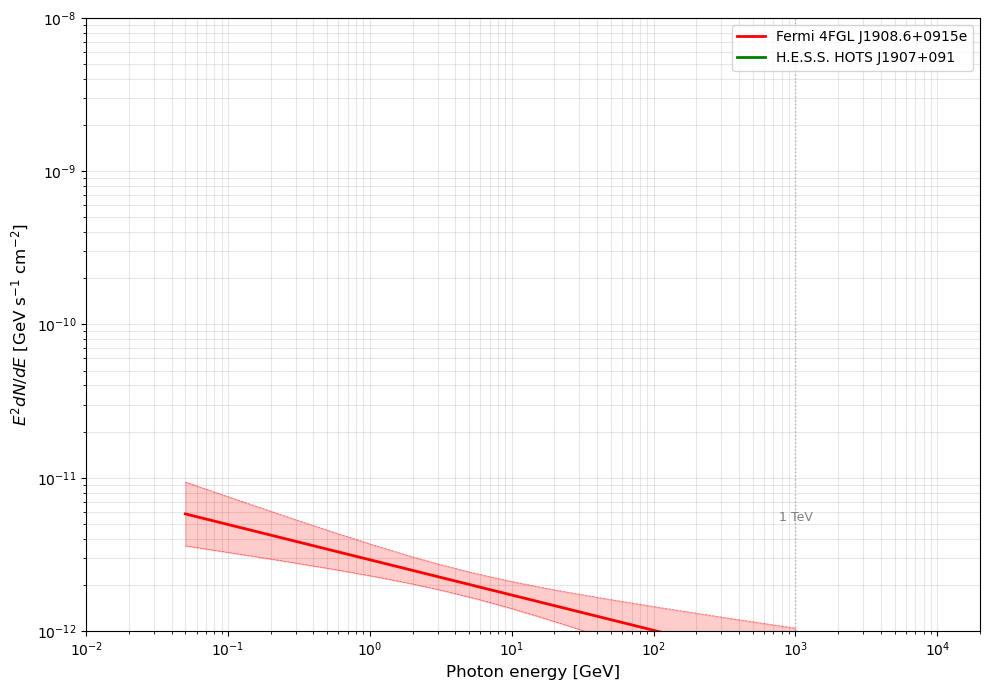

Generating detailed comparison plot...


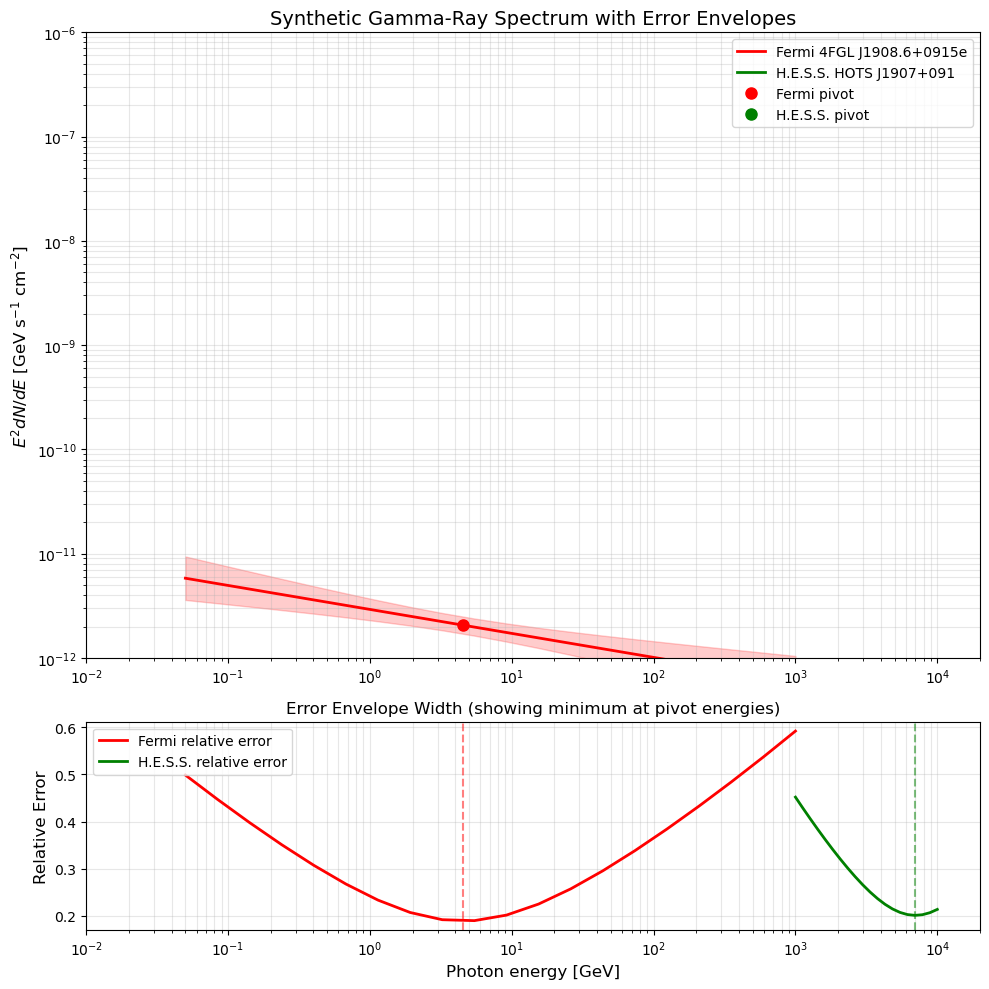


Plots saved successfully!


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

class SyntheticGammaRaySpectrum:
    """
    Generates synthetic gamma-ray spectrum matching the methodology from
    Hnatyk et al. 2022 paper for SGR 1900+14 region
    """
    
    def __init__(self):
        # Fermi-LAT 4FGL J1908.6+0915e parameters
        self.fermi_pivot = 4.52  # GeV
        self.fermi_norm = 1.01e-13  # ph cm^-2 s^-1 MeV^-1
        self.fermi_norm_err = 0.19e-13
        self.fermi_index = 2.23
        self.fermi_index_err = 0.098
        self.fermi_emin = 0.05  # 50 MeV
        self.fermi_emax = 1000.0  # 1 TeV
        
        # H.E.S.S. HOTS J1907+091 parameters
        self.hess_pivot = 7.0  # TeV (approximate for 1-10 TeV range)
        self.hess_index = 2.3
        self.hess_index_err = 0.2
        self.hess_flux_integral = 4.3e-13  # cm^-2 s^-1 for E > 1 TeV
        self.hess_relative_err = 0.2  # 20% fractional uncertainty
        self.hess_emin = 1000.0  # 1 TeV in GeV
        self.hess_emax = 10000.0  # 10 TeV in GeV
        
        # Calculate H.E.S.S. normalization from integral flux
        self.hess_norm = self._calculate_hess_normalization()
        
    def _calculate_hess_normalization(self):
        """
        Calculate differential flux normalization from integral flux
        For power-law: F(>E) = F0 * E0^Γ / (Γ-1) * E^(1-Γ)
        """
        gamma = self.hess_index
        E_min = self.hess_emin * 1e-3  # Convert to TeV
        
        # Integral flux formula for power law
        # F(>E) = F0 / (gamma - 1) * (E/E0)^(-gamma+1)
        # Solving for F0 at pivot energy
        integral_factor = 1.0 / (gamma - 1) * (E_min / self.hess_pivot)**(1 - gamma)
        F0_TeV = self.hess_flux_integral / integral_factor  # TeV^-1 cm^-2 s^-1
        
        # Convert to GeV^-1 cm^-2 s^-1
        F0_GeV = F0_TeV * 1e3  # because 1 TeV^-1 = 1000 GeV^-1
        
        return F0_GeV
        
    def power_law_flux(self, energy, pivot, norm, index):
        """
        Calculate power-law differential flux
        F(E) = F0 * (E/E0)^(-Γ)
        
        Parameters:
        -----------
        energy : array-like
            Photon energy in GeV
        pivot : float
            Pivot energy in GeV
        norm : float
            Normalization at pivot energy
        index : float
            Spectral index
        """
        return norm * (energy / pivot)**(-index)
    
    def generate_fermi_spectrum(self, n_bins=20):
        """
        Generate Fermi-LAT spectrum with uncertainties
        """
        # Logarithmically spaced energies
        energies = np.logspace(np.log10(self.fermi_emin), 
                              np.log10(self.fermi_emax), 
                              n_bins)
        
        # Central flux values
        flux = self.power_law_flux(energies, self.fermi_pivot, 
                                   self.fermi_norm, self.fermi_index)
        
        # Calculate uncertainties using error propagation
        # δF/F = sqrt((δF0/F0)^2 + (ln(E/E0) * δΓ)^2)
        relative_norm_err = self.fermi_norm_err / self.fermi_norm
        log_energy_ratio = np.log(energies / self.fermi_pivot)
        
        # Relative uncertainty
        relative_error = np.sqrt(relative_norm_err**2 + 
                                (log_energy_ratio * self.fermi_index_err)**2)
        
        # Absolute uncertainties (asymmetric due to log-normal distribution)
        # In log-space, errors are more symmetric
        # For flux, we use multiplicative errors
        flux_err_low = flux * (1 - np.exp(-relative_error))
        flux_err_high = flux * (np.exp(relative_error) - 1)
        
        # Convert to E^2 dN/dE for plotting
        e2_flux = energies**2 * flux
        e2_flux_err_low = energies**2 * flux_err_low
        e2_flux_err_high = energies**2 * flux_err_high
        
        return energies, e2_flux, e2_flux_err_low, e2_flux_err_high
    
    def generate_hess_spectrum(self, n_bins=20):
        """
        Generate H.E.S.S. spectrum with uncertainties
        """
        # Logarithmically spaced energies in TeV range
        energies = np.logspace(np.log10(self.hess_emin), 
                              np.log10(self.hess_emax), 
                              n_bins)
        
        # Central flux values
        flux = self.power_law_flux(energies, self.hess_pivot * 1e3,  # Convert to GeV
                                   self.hess_norm, self.hess_index)
        
        # H.E.S.S. has larger fractional uncertainty (20%)
        # Similar error propagation but with different pivot
        relative_norm_err = self.hess_relative_err
        log_energy_ratio = np.log(energies / (self.hess_pivot * 1e3))
        
        relative_error = np.sqrt(relative_norm_err**2 + 
                                (log_energy_ratio * self.hess_index_err)**2)
        
        # Asymmetric errors
        flux_err_low = flux * (1 - np.exp(-relative_error))
        flux_err_high = flux * (np.exp(relative_error) - 1)
        
        # Convert to E^2 dN/dE
        e2_flux = energies**2 * flux
        e2_flux_err_low = energies**2 * flux_err_low
        e2_flux_err_high = energies**2 * flux_err_high
        
        return energies, e2_flux, e2_flux_err_low, e2_flux_err_high
    
    def plot_spectrum(self, save_path=None):
        """
        Create a plot similar to Figure 3 from the paper
        """
        # Generate spectra
        fermi_e, fermi_flux, fermi_err_low, fermi_err_high = self.generate_fermi_spectrum()
        hess_e, hess_flux, hess_err_low, hess_err_high = self.generate_hess_spectrum()
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Plot Fermi-LAT spectrum
        ax.plot(fermi_e, fermi_flux, 'r-', linewidth=2, 
                label='Fermi 4FGL J1908.6+0915e', zorder=3)
        ax.fill_between(fermi_e, 
                        fermi_flux - fermi_err_low,
                        fermi_flux + fermi_err_high,
                        color='red', alpha=0.2, zorder=2)
        
        # Plot error envelope lines
        ax.plot(fermi_e, fermi_flux - fermi_err_low, 'r--', 
                linewidth=0.5, alpha=0.5)
        ax.plot(fermi_e, fermi_flux + fermi_err_high, 'r--', 
                linewidth=0.5, alpha=0.5)
        
        # Plot H.E.S.S. spectrum
        ax.plot(hess_e, hess_flux, 'g-', linewidth=2, 
                label='H.E.S.S. HOTS J1907+091', zorder=3)
        ax.fill_between(hess_e, 
                        hess_flux - hess_err_low,
                        hess_flux + hess_err_high,
                        color='green', alpha=0.2, zorder=2)
        
        # Plot error envelope lines
        ax.plot(hess_e, hess_flux - hess_err_low, 'g--', 
                linewidth=0.5, alpha=0.5)
        ax.plot(hess_e, hess_flux + hess_err_high, 'g--', 
                linewidth=0.5, alpha=0.5)
        
        # Formatting
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Photon energy [GeV]', fontsize=12)
        ax.set_ylabel(r'$E^2 dN/dE$ [GeV s$^{-1}$ cm$^{-2}$]', fontsize=12)
        ax.set_xlim(0.01, 20000)
        ax.set_ylim(1e-12, 1e-8)
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3, which='both')
        
        # Add vertical line at transition energy
        ax.axvline(1000, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        ax.text(1000, 5e-12, '1 TeV', rotation=0, fontsize=9, 
                ha='center', va='bottom', color='gray')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        return fig, ax
    
    def analyze_error_envelope(self):
        """
        Analyze and print characteristics of the error envelope
        """
        fermi_e, fermi_flux, fermi_err_low, fermi_err_high = self.generate_fermi_spectrum()
        hess_e, hess_flux, hess_err_low, hess_err_high = self.generate_hess_spectrum()
        
        print("=" * 60)
        print("Error Envelope Analysis")
        print("=" * 60)
        
        # Fermi-LAT analysis
        fermi_rel_err = (fermi_err_low + fermi_err_high) / (2 * fermi_flux)
        print("\nFermi-LAT (50 MeV - 1 TeV):")
        print(f"  Pivot energy: {self.fermi_pivot} GeV")
        print(f"  Min relative error: {fermi_rel_err.min():.3f} at {fermi_e[fermi_rel_err.argmin()]:.2f} GeV")
        print(f"  Max relative error: {fermi_rel_err.max():.3f} at {fermi_e[fermi_rel_err.argmax()]:.2f} GeV")
        print(f"  Error at lowest energy: {fermi_rel_err[0]:.3f}")
        print(f"  Error at highest energy: {fermi_rel_err[-1]:.3f}")
        
        # H.E.S.S. analysis
        hess_rel_err = (hess_err_low + hess_err_high) / (2 * hess_flux)
        print("\nH.E.S.S. (1 TeV - 10 TeV):")
        print(f"  Pivot energy: {self.hess_pivot} TeV")
        print(f"  Min relative error: {hess_rel_err.min():.3f} at {hess_e[hess_rel_err.argmin()]:.2f} GeV")
        print(f"  Max relative error: {hess_rel_err.max():.3f} at {hess_e[hess_rel_err.argmax()]:.2f} GeV")
        print(f"  Error at lowest energy: {hess_rel_err[0]:.3f}")
        print(f"  Error at highest energy: {hess_rel_err[-1]:.3f}")
        
        print("\n" + "=" * 60)
        print("Error Envelope Shape Explanation:")
        print("=" * 60)
        print("1. Errors are SMALLEST at the pivot energy (where fit is anchored)")
        print("2. Errors GROW moving away from pivot (bow-tie pattern)")
        print("3. Growth rate depends on spectral index uncertainty")
        print("4. H.E.S.S. has larger baseline uncertainty (20% vs ~19%)")
        print("5. Asymmetric errors arise from multiplicative/log-normal nature")
        print("=" * 60)


def create_detailed_comparison_plot():
    """
    Create a more detailed plot showing the error structure
    """
    spectrum = SyntheticGammaRaySpectrum()
    
    fermi_e, fermi_flux, fermi_err_low, fermi_err_high = spectrum.generate_fermi_spectrum()
    hess_e, hess_flux, hess_err_low, hess_err_high = spectrum.generate_hess_spectrum()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), 
                                    gridspec_kw={'height_ratios': [3, 1]})
    
    # Main spectrum plot
    ax1.plot(fermi_e, fermi_flux, 'r-', linewidth=2, 
             label='Fermi 4FGL J1908.6+0915e')
    ax1.fill_between(fermi_e, 
                     fermi_flux - fermi_err_low,
                     fermi_flux + fermi_err_high,
                     color='red', alpha=0.2)
    
    ax1.plot(hess_e, hess_flux, 'g-', linewidth=2, 
             label='H.E.S.S. HOTS J1907+091')
    ax1.fill_between(hess_e, 
                     hess_flux - hess_err_low,
                     hess_flux + hess_err_high,
                     color='green', alpha=0.2)
    
    # Mark pivot points
    fermi_pivot_flux = spectrum.power_law_flux(spectrum.fermi_pivot, 
                                               spectrum.fermi_pivot, 
                                               spectrum.fermi_norm, 
                                               spectrum.fermi_index)
    ax1.plot(spectrum.fermi_pivot, spectrum.fermi_pivot**2 * fermi_pivot_flux, 
             'ro', markersize=8, label='Fermi pivot', zorder=5)
    
    hess_pivot_flux = spectrum.power_law_flux(spectrum.hess_pivot * 1e3, 
                                              spectrum.hess_pivot * 1e3, 
                                              spectrum.hess_norm, 
                                              spectrum.hess_index)
    ax1.plot(spectrum.hess_pivot * 1e3, (spectrum.hess_pivot * 1e3)**2 * hess_pivot_flux, 
             'go', markersize=8, label='H.E.S.S. pivot', zorder=5)
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_ylabel(r'$E^2 dN/dE$ [GeV s$^{-1}$ cm$^{-2}$]', fontsize=12)
    ax1.set_xlim(0.01, 20000)
    ax1.set_ylim(1e-12, 1e-6)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.set_title('Synthetic Gamma-Ray Spectrum with Error Envelopes', fontsize=14)
    
    # Relative error plot
    fermi_rel_err = (fermi_err_low + fermi_err_high) / (2 * fermi_flux)
    hess_rel_err = (hess_err_low + hess_err_high) / (2 * hess_flux)
    
    ax2.plot(fermi_e, fermi_rel_err, 'r-', linewidth=2, label='Fermi relative error')
    ax2.plot(hess_e, hess_rel_err, 'g-', linewidth=2, label='H.E.S.S. relative error')
    ax2.axvline(spectrum.fermi_pivot, color='red', linestyle='--', alpha=0.5)
    ax2.axvline(spectrum.hess_pivot * 1e3, color='green', linestyle='--', alpha=0.5)
    
    ax2.set_xscale('log')
    ax2.set_xlabel('Photon energy [GeV]', fontsize=12)
    ax2.set_ylabel('Relative Error', fontsize=12)
    ax2.set_xlim(0.01, 20000)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_title('Error Envelope Width (showing minimum at pivot energies)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('spectrum_with_error_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


# Main execution
if __name__ == "__main__":
    print("Generating Synthetic Gamma-Ray Spectrum")
    print("Based on Hnatyk et al. 2022 methodology\n")
    
    # Create spectrum object
    spectrum = SyntheticGammaRaySpectrum()
    
    # Analyze error envelope characteristics
    spectrum.analyze_error_envelope()
    
    # Create basic plot
    print("\nGenerating basic spectrum plot...")
    spectrum.plot_spectrum(save_path='synthetic_spectrum_basic.png')
    
    # Create detailed comparison plot
    print("Generating detailed comparison plot...")
    create_detailed_comparison_plot()
    
    print("\nPlots saved successfully!")

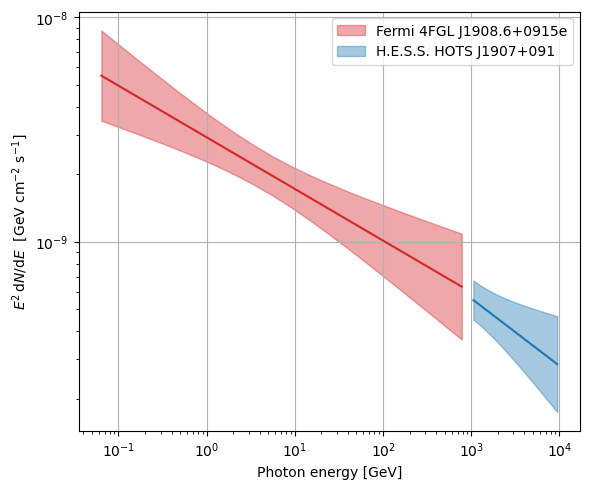

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def load_sed(fname):
    data = np.loadtxt(fname)
    E, Elo, Ehi, F, Ferr_lo, Ferr_hi = data.T
    return E, Elo, Ehi, F

# ------- load central synthetic spectra (no need for errors here) -------
E_f, Elo_f, Ehi_f, F_f = load_sed("FERMI_SYN_50MeV_1TeV.txt")
E_h, Elo_h, Ehi_h, F_h = load_sed("HESS_SYN_1TeV_10TeV.txt")

# ----------------- Fermi band: PL with N0 + Gamma errors -----------------
# From the paper / 4FGL:
E0_F = 4.52          # GeV, pivot energy
Gamma_F = 2.23
sigma_Gamma_F = 0.098      # index error
rel_sys_F = 0.20           # they assume δF/F = 0.2 as “std dev”

# error in ln F(E): combination of norm error and index error
sigma_logF_F = np.sqrt(rel_sys_F**2 + (np.log(E_f / E0_F) * sigma_Gamma_F)**2)

SED_f = E_f**2 * F_f
SED_f_lo = SED_f * np.exp(-sigma_logF_F)
SED_f_hi = SED_f * np.exp(+sigma_logF_F)

# ----------------- HESS band: PL with N0 + Gamma errors ------------------
# From the paper for HOTS J1907+091:
E0_H = 1000.0       # GeV, 1 TeV where N0 is defined
Gamma_H = 2.3
sigma_Gamma_H = 0.2
rel_sys_H = 0.20    # again δF/F = 0.2 as “std dev”

sigma_logF_H = np.sqrt(rel_sys_H**2 + (np.log(E_h / E0_H) * sigma_Gamma_H)**2)

SED_h = E_h**2 * F_h
SED_h_lo = SED_h * np.exp(-sigma_logF_H)
SED_h_hi = SED_h * np.exp(+sigma_logF_H)

# ----------------- plot -----------------
fig, ax = plt.subplots(figsize=(6, 5))

# Fermi (red)
ax.fill_between(E_f, SED_f_lo, SED_f_hi,
                alpha=0.4, color="tab:red", label="Fermi 4FGL J1908.6+0915e")
ax.plot(E_f, SED_f, color="tab:red")

# HESS (blue)
ax.fill_between(E_h, SED_h_lo, SED_h_hi,
                alpha=0.4, color="tab:blue", label="H.E.S.S. HOTS J1907+091")
ax.plot(E_h, SED_h, color="tab:blue")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Photon energy [GeV]")
ax.set_ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E$  [GeV cm$^{-2}$ s$^{-1}$]")
ax.legend(loc="best")

ax.xaxis.set_minor_locator(mticker.LogLocator(subs="auto"))
ax.yaxis.set_minor_locator(mticker.LogLocator(subs="auto"))

plt.grid()
plt.tight_layout()
plt.show()

Generating Synthetic Gamma-Ray Spectrum
Based on Hnatyk et al. 2022 methodology

Error Envelope Analysis

Fermi-LAT (50 MeV - 1 TeV):
  Pivot energy: 4.52 GeV
  Flux at pivot: 1.977e-09 GeV cm^-2 s^-1
  Min relative error: 0.190 at 5.45 GeV
  Max relative error: 0.592 at 1000.00 GeV
  Error at lowest energy: 0.498
  Error at highest energy: 0.592

H.E.S.S. (1 TeV - 10 TeV):
  Pivot energy: 7.0 TeV = 7000.0 GeV
  Flux at 1 TeV: 3.913e-09 GeV cm^-2 s^-1
  Min relative error: 0.201 at 6951.93 GeV
  Max relative error: 0.452 at 1000.00 GeV
  Error at lowest energy: 0.452
  Error at highest energy: 0.214


Generating basic spectrum plot...


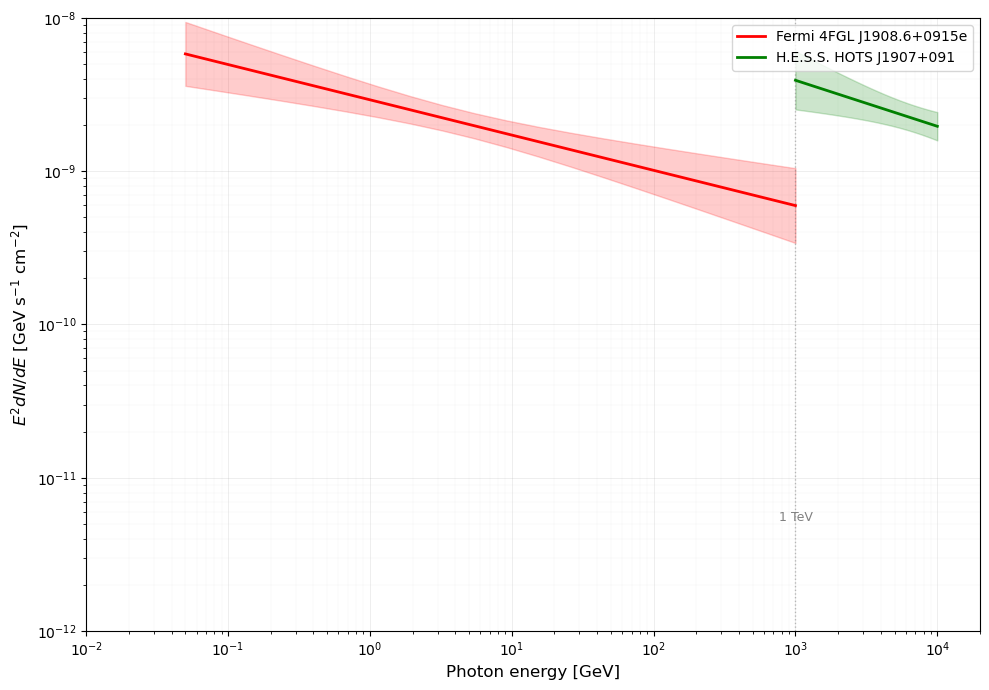


Generating detailed comparison plot...


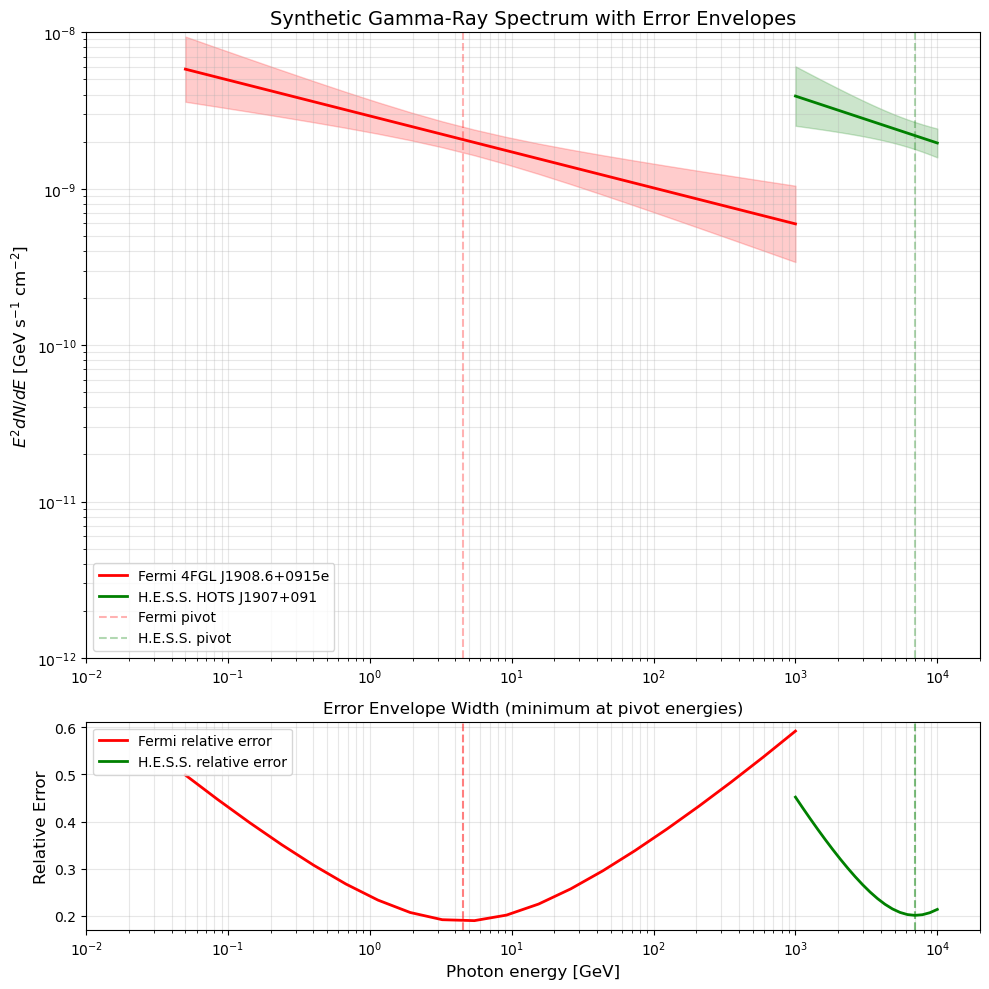


Plots saved successfully!


In [14]:
import numpy as np
import matplotlib.pyplot as plt

class SyntheticGammaRaySpectrum:
    """
    Generates synthetic gamma-ray spectrum matching the methodology from
    Hnatyk et al. 2022 paper for SGR 1900+14 region
    """
    
    def __init__(self):
        # Fermi-LAT 4FGL J1908.6+0915e parameters
        self.fermi_pivot = 4.52  # GeV
        self.fermi_norm = 1.01e-13  # ph cm^-2 s^-1 MeV^-1
        self.fermi_norm_err = 0.19e-13
        self.fermi_index = 2.23
        self.fermi_index_err = 0.098
        self.fermi_emin = 0.05  # 50 MeV in GeV
        self.fermi_emax = 1000.0  # 1 TeV in GeV
        
        # H.E.S.S. HOTS J1907+091 parameters
        self.hess_pivot = 7.0  # TeV (reference energy)
        self.hess_index = 2.3
        self.hess_index_err = 0.2
        self.hess_flux_integral = 4.3e-13  # cm^-2 s^-1 for E > 1 TeV
        self.hess_relative_err = 0.2  # 20% fractional uncertainty
        self.hess_emin = 1000.0  # 1 TeV in GeV
        self.hess_emax = 10000.0  # 10 TeV in GeV
        
        # Calculate H.E.S.S. normalization from integral flux
        self.hess_norm = self._calculate_hess_normalization()
        
    def _calculate_hess_normalization(self):
        """
        Calculate differential flux normalization from integral flux
        For power-law: F(>E) = F0 / (Γ-1) * (E/E0)^(1-Γ)
        """
        gamma = self.hess_index
        E_min = self.hess_emin / 1000.0  # Convert to TeV
        E0 = self.hess_pivot  # TeV
        
        # Integral flux: F(>E) = F0 / (gamma - 1) * (E/E0)^(1-gamma)
        # Solve for F0
        integral_factor = 1.0 / (gamma - 1) * (E_min / E0)**(1 - gamma)
        F0_TeV = self.hess_flux_integral / integral_factor  # TeV^-1 cm^-2 s^-1
        
        return F0_TeV
        
    def power_law_flux(self, energy, pivot, norm, index):
        """
        Calculate power-law differential flux
        F(E) = F0 * (E/E0)^(-Γ)
        
        Parameters:
        -----------
        energy : array-like
            Photon energy in GeV
        pivot : float
            Pivot energy in same units as energy
        norm : float
            Normalization at pivot energy
        index : float
            Spectral index
        """
        return norm * (energy / pivot)**(-index)
    
    def generate_fermi_spectrum(self, n_bins=20):
        """
        Generate Fermi-LAT spectrum with uncertainties
        """
        # Logarithmically spaced energies
        energies = np.logspace(np.log10(self.fermi_emin), 
                              np.log10(self.fermi_emax), 
                              n_bins)
        
        # Central flux values
        # F_ph is in MeV^-1, energies in GeV
        # Need to convert: when E is in GeV and F is per MeV, multiply by 1000 to get per GeV
        flux = self.power_law_flux(energies, self.fermi_pivot, 
                                   self.fermi_norm * 1000.0,  # Convert MeV^-1 to GeV^-1
                                   self.fermi_index)
        
        # Calculate uncertainties using error propagation
        # δF/F = sqrt((δF0/F0)^2 + (ln(E/E0) * δΓ)^2)
        relative_norm_err = self.fermi_norm_err / self.fermi_norm
        log_energy_ratio = np.log(energies / self.fermi_pivot)
        
        # Relative uncertainty
        relative_error = np.sqrt(relative_norm_err**2 + 
                                (log_energy_ratio * self.fermi_index_err)**2)
        
        # Asymmetric errors (multiplicative in log-space)
        flux_err_low = flux * (1 - np.exp(-relative_error))
        flux_err_high = flux * (np.exp(relative_error) - 1)
        
        # Convert to E^2 dN/dE for plotting (GeV cm^-2 s^-1)
        e2_flux = energies**2 * flux
        e2_flux_err_low = energies**2 * flux_err_low
        e2_flux_err_high = energies**2 * flux_err_high
        
        return energies, e2_flux, e2_flux_err_low, e2_flux_err_high
    
    def generate_hess_spectrum(self, n_bins=20):
        """
        Generate H.E.S.S. spectrum with uncertainties
        """
        # Logarithmically spaced energies
        energies = np.logspace(np.log10(self.hess_emin), 
                              np.log10(self.hess_emax), 
                              n_bins)
        
        # Convert energies to TeV for H.E.S.S. calculation
        energies_TeV = energies / 1000.0
        
        # Central flux values (in TeV^-1)
        flux_TeV = self.power_law_flux(energies_TeV, self.hess_pivot,
                                       self.hess_norm, self.hess_index)
        
        # Convert to GeV^-1 by dividing by 1000 (since if you have X per TeV, you have X/1000 per GeV)
        flux = flux_TeV / 1000.0
        
        # Calculate uncertainties
        relative_norm_err = self.hess_relative_err
        log_energy_ratio = np.log(energies_TeV / self.hess_pivot)
        
        relative_error = np.sqrt(relative_norm_err**2 + 
                                (log_energy_ratio * self.hess_index_err)**2)
        
        # Asymmetric errors
        flux_err_low = flux * (1 - np.exp(-relative_error))
        flux_err_high = flux * (np.exp(relative_error) - 1)
        
        # Convert to E^2 dN/dE (GeV cm^-2 s^-1)
        e2_flux = energies**2 * flux
        e2_flux_err_low = energies**2 * flux_err_low
        e2_flux_err_high = energies**2 * flux_err_high
        
        return energies, e2_flux, e2_flux_err_low, e2_flux_err_high
    
    def plot_spectrum(self, save_path=None):
        """
        Create a plot similar to Figure 3 from the paper
        """
        # Generate spectra
        fermi_e, fermi_flux, fermi_err_low, fermi_err_high = self.generate_fermi_spectrum()
        hess_e, hess_flux, hess_err_low, hess_err_high = self.generate_hess_spectrum()
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Plot Fermi-LAT spectrum
        ax.plot(fermi_e, fermi_flux, 'r-', linewidth=2, 
                label='Fermi 4FGL J1908.6+0915e', zorder=3)
        ax.fill_between(fermi_e, 
                        fermi_flux - fermi_err_low,
                        fermi_flux + fermi_err_high,
                        color='red', alpha=0.2, zorder=2)
        
        # Plot H.E.S.S. spectrum
        ax.plot(hess_e, hess_flux, 'g-', linewidth=2, 
                label='H.E.S.S. HOTS J1907+091', zorder=3)
        ax.fill_between(hess_e, 
                        hess_flux - hess_err_low,
                        hess_flux + hess_err_high,
                        color='green', alpha=0.2, zorder=2)
        
        # Formatting
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Photon energy [GeV]', fontsize=12)
        ax.set_ylabel(r'$E^2 dN/dE$ [GeV s$^{-1}$ cm$^{-2}$]', fontsize=12)
        ax.set_xlim(0.01, 20000)
        ax.set_ylim(1e-12, 1e-8)
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
        ax.grid(True, alpha=0.15, which='minor', linestyle='-', linewidth=0.3)
        
        # Add vertical line at transition energy
        ax.axvline(1000, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        ax.text(1000, 5e-12, '1 TeV', rotation=0, fontsize=9, 
                ha='center', va='bottom', color='gray')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        return fig, ax
    
    def analyze_error_envelope(self):
        """
        Analyze and print characteristics of the error envelope
        """
        fermi_e, fermi_flux, fermi_err_low, fermi_err_high = self.generate_fermi_spectrum()
        hess_e, hess_flux, hess_err_low, hess_err_high = self.generate_hess_spectrum()
        
        print("=" * 60)
        print("Error Envelope Analysis")
        print("=" * 60)
        
        # Fermi-LAT analysis
        fermi_rel_err = (fermi_err_low + fermi_err_high) / (2 * fermi_flux)
        print("\nFermi-LAT (50 MeV - 1 TeV):")
        print(f"  Pivot energy: {self.fermi_pivot} GeV")
        print(f"  Flux at pivot: {fermi_flux[np.argmin(np.abs(fermi_e - self.fermi_pivot))]:.3e} GeV cm^-2 s^-1")
        print(f"  Min relative error: {fermi_rel_err.min():.3f} at {fermi_e[fermi_rel_err.argmin()]:.2f} GeV")
        print(f"  Max relative error: {fermi_rel_err.max():.3f} at {fermi_e[fermi_rel_err.argmax()]:.2f} GeV")
        print(f"  Error at lowest energy: {fermi_rel_err[0]:.3f}")
        print(f"  Error at highest energy: {fermi_rel_err[-1]:.3f}")
        
        # H.E.S.S. analysis
        hess_rel_err = (hess_err_low + hess_err_high) / (2 * hess_flux)
        print("\nH.E.S.S. (1 TeV - 10 TeV):")
        print(f"  Pivot energy: {self.hess_pivot} TeV = {self.hess_pivot*1000} GeV")
        print(f"  Flux at 1 TeV: {hess_flux[0]:.3e} GeV cm^-2 s^-1")
        print(f"  Min relative error: {hess_rel_err.min():.3f} at {hess_e[hess_rel_err.argmin()]:.2f} GeV")
        print(f"  Max relative error: {hess_rel_err.max():.3f} at {hess_e[hess_rel_err.argmax()]:.2f} GeV")
        print(f"  Error at lowest energy: {hess_rel_err[0]:.3f}")
        print(f"  Error at highest energy: {hess_rel_err[-1]:.3f}")
        
        print("\n" + "=" * 60)


def create_detailed_comparison_plot():
    """
    Create a more detailed plot showing the error structure
    """
    spectrum = SyntheticGammaRaySpectrum()
    
    fermi_e, fermi_flux, fermi_err_low, fermi_err_high = spectrum.generate_fermi_spectrum()
    hess_e, hess_flux, hess_err_low, hess_err_high = spectrum.generate_hess_spectrum()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), 
                                    gridspec_kw={'height_ratios': [3, 1]})
    
    # Main spectrum plot
    ax1.plot(fermi_e, fermi_flux, 'r-', linewidth=2, 
             label='Fermi 4FGL J1908.6+0915e')
    ax1.fill_between(fermi_e, 
                     fermi_flux - fermi_err_low,
                     fermi_flux + fermi_err_high,
                     color='red', alpha=0.2)
    
    ax1.plot(hess_e, hess_flux, 'g-', linewidth=2, 
             label='H.E.S.S. HOTS J1907+091')
    ax1.fill_between(hess_e, 
                     hess_flux - hess_err_low,
                     hess_flux + hess_err_high,
                     color='green', alpha=0.2)
    
    # Mark pivot points
    ax1.axvline(spectrum.fermi_pivot, color='red', linestyle='--', 
                alpha=0.3, label='Fermi pivot')
    ax1.axvline(spectrum.hess_pivot * 1000, color='green', linestyle='--', 
                alpha=0.3, label='H.E.S.S. pivot')
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_ylabel(r'$E^2 dN/dE$ [GeV s$^{-1}$ cm$^{-2}$]', fontsize=12)
    ax1.set_xlim(0.01, 20000)
    ax1.set_ylim(1e-12, 1e-8)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.set_title('Synthetic Gamma-Ray Spectrum with Error Envelopes', fontsize=14)
    
    # Relative error plot
    fermi_rel_err = (fermi_err_low + fermi_err_high) / (2 * fermi_flux)
    hess_rel_err = (hess_err_low + hess_err_high) / (2 * hess_flux)
    
    ax2.plot(fermi_e, fermi_rel_err, 'r-', linewidth=2, label='Fermi relative error')
    ax2.plot(hess_e, hess_rel_err, 'g-', linewidth=2, label='H.E.S.S. relative error')
    ax2.axvline(spectrum.fermi_pivot, color='red', linestyle='--', alpha=0.5)
    ax2.axvline(spectrum.hess_pivot * 1000, color='green', linestyle='--', alpha=0.5)
    
    ax2.set_xscale('log')
    ax2.set_xlabel('Photon energy [GeV]', fontsize=12)
    ax2.set_ylabel('Relative Error', fontsize=12)
    ax2.set_xlim(0.01, 20000)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_title('Error Envelope Width (minimum at pivot energies)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('spectrum_with_error_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


# Main execution
if __name__ == "__main__":
    print("Generating Synthetic Gamma-Ray Spectrum")
    print("Based on Hnatyk et al. 2022 methodology\n")
    
    # Create spectrum object
    spectrum = SyntheticGammaRaySpectrum()
    
    # Analyze error envelope characteristics
    spectrum.analyze_error_envelope()
    
    # Create basic plot
    print("\nGenerating basic spectrum plot...")
    spectrum.plot_spectrum(save_path='synthetic_spectrum_basic.png')
    
    # Create detailed comparison plot
    print("\nGenerating detailed comparison plot...")
    create_detailed_comparison_plot()
    
    print("\nPlots saved successfully!")